<a href="https://colab.research.google.com/github/AnnaZapototska/goit-colab-homeworks/blob/development/hw_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

iris = load_iris()

df = pd.DataFrame(
    data=iris.data,
    columns=iris.feature_names
)
# Add clasess name
df['species'] = [iris.target_names[i] for i in iris.target]

print("Basic Statistic Information:")
df.describe()


Basic Statistic Information:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


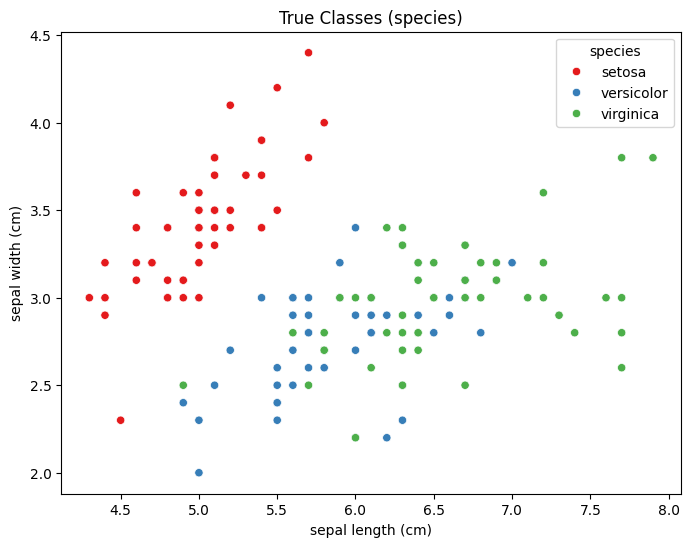

In [ ]:
# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="species",
    palette="Set1"
)

plt.title("True Classes (species)")
plt.show()

In [ ]:
# df.info()
features = df.drop(columns=['species'])

scaler = StandardScaler()
scaled_data = scaler.set_output(transform='pandas').fit_transform(features)
scaled_data.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-1.468455e-15,-1.823726e-15,-1.610564e-15,-9.473903e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.433947e+00,-1.567576e+00,-1.447076e+00
25%,-9.006812e-01,-5.923730e-01,-1.226552e+00,-1.183812e+00
50%,-5.250608e-02,-1.319795e-01,3.364776e-01,1.325097e-01
75%,6.745011e-01,5.586108e-01,7.627583e-01,7.906707e-01
max,2.492019e+00,3.090775e+00,1.785832e+00,1.712096e+00


In [ ]:
spectral = SpectralClustering(
    n_clusters=3,
    affinity='nearest_neighbors',
    assign_labels='kmeans',
    random_state=42
)

predicted_labels = spectral.fit_predict(scaled_data)

df["predicted_label"] = predicted_labels
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,predicted_label
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


In [ ]:
cm = confusion_matrix(
    iris.target,
    df["predicted_label"]
)

print(cm)

[[ 0 49  1]
 [ 3  0 47]
 [32  0 18]]


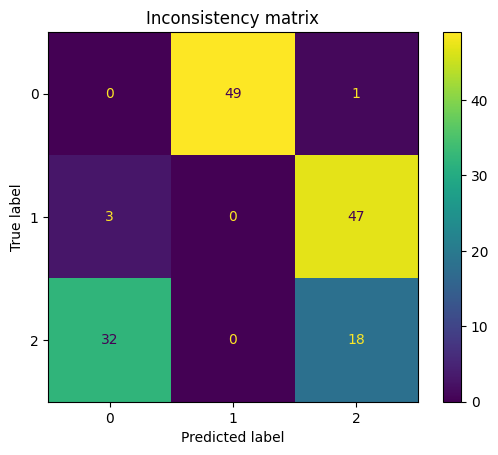

In [ ]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Inconsistency matrix")
plt.show()

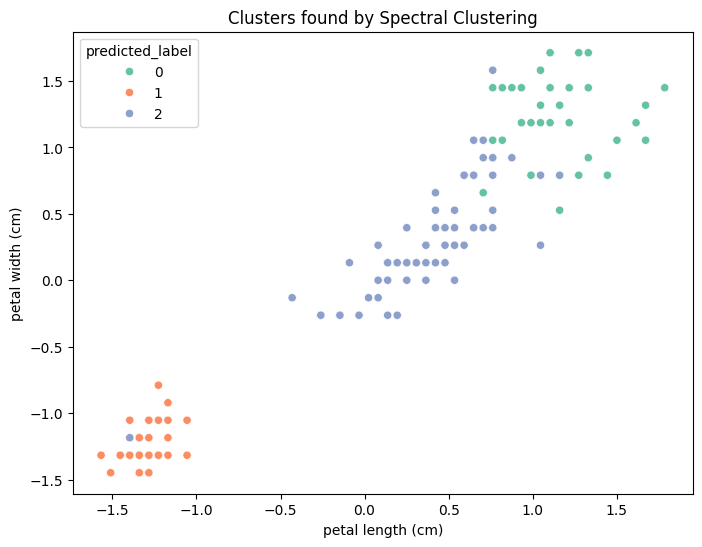

In [ ]:
plot_df = scaled_data.copy()
plot_df["predicted_label"] = predicted_labels

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=plot_df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="predicted_label",
    palette="Set2"
)

plt.title("Clusters found by Spectral Clustering")
plt.show()


# Conclusion

In this work, the Iris dataset was loaded and analyzed using the pandas library. Basic statistical characteristics of the dataset were obtained using the describe() function.

The distribution of observations across classes was visualized using seaborn. Before clustering, the numerical features were standardized using StandardScaler to ensure that all features contributed equally to the analysis.

Spectral Clustering was then applied to group the observations into three clusters. The clustering results were compared with the actual Iris classes using a confusion matrix.

The results show that the algorithm successfully identified the Setosa class, with 49 out of 50 observations assigned to the same cluster. The Versicolor class was also clustered effectively, with 47 out of 50 observations grouped together. However, the Virginica class was partially mixed with Versicolor, indicating that these two species have similar characteristics and are more difficult to separate.

Although cluster labels do not necessarily correspond directly to the original class labels, the experiment demonstrates that Spectral Clustering is able to discover meaningful patterns and the underlying structure of the Iris dataset. Overall, the algorithm performed well, especially in identifying the Setosa species, while showing some limitations when distinguishing between Versicolor and Virginica.